In [1]:
import polars as pl

lf = pl.LazyFrame({
    'x': [1.0, 2.0, 3.0, 4.0, 5.0],
    'y': [2.5, 3.5, 4.5, 5.5, 6.5]
})

In [2]:

import pandas as pd
from polars import col


def test(data: pd.DataFrame) -> pd.DataFrame:
    data["z"] = data["x"]+data["y"]
    return data

# .pipe(lambda x: 2*col("x")).collect()

In [3]:
lf.pipe(lambda x: x.with_columns((col("x") + 10).alias("x_plus_10"))).collect()

x,y,x_plus_10
f64,f64,f64
1.0,2.5,11.0
2.0,3.5,12.0
3.0,4.5,13.0
4.0,5.5,14.0
5.0,6.5,15.0


In [4]:
lf.map_batches(test).collect()

TypeError: DataFrame object does not support `Series` assignment by index

Use `DataFrame.with_columns`.

In [5]:
from hamilton.htypes import Parallelizable, Collect

In [1]:
%load_ext hamilton.plugins.jupyter_magic

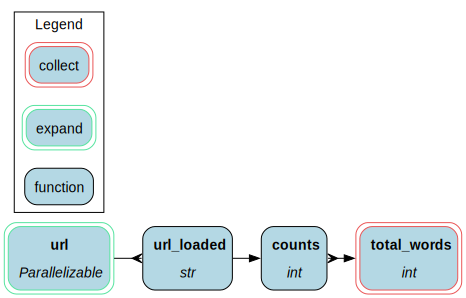

In [6]:
%%cell_to_module -m MODULE_NAME --display --rebuild-drivers

from hamilton.htypes import Parallelizable, Collect

def url() -> Parallelizable[str]:
    for url_ in  _list_all_urls():
        yield url_

def url_loaded(url: str) -> str:
    return _load(urls)

def counts(url_loaded: str) -> int:
    return len(url_loaded.split(" "))

def total_words(counts: Collect[int]) -> int:
    return sum(counts)

In [13]:
import os
os.environ["PATH"] = "/opt/miniconda/envs/spockappdev/bin:/opt/miniconda/condabin:/Users/cp371651/.nvm/versions/node/v20.11.0/bin:/Users/cp371651/.kube/plugins:/opt/homebrew/opt/openjdk@17/bin:/Users/cp371651/.rd/bin:/Users/cp371651/Library/Application Support/Code/User/globalStorage/github.copilot-chat/debugCommand:/Users/cp371651/Library/Application Support/Code/User/globalStorage/github.copilot-chat/copilotCli:/usr/local/bin:/System/Cryptexes/App/usr/bin:/usr/bin:/bin:/usr/sbin:/sbin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/local/bin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/bin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/appleinternal/bin:/usr/local/sbin:/Users/cp371651/Library/Application Support/Code/User/globalStorage/github.copilot-chat/debugCommand:/Users/cp371651/Library/Application Support/Code/User/globalStorage/github.copilot-chat/copilotCli:/Users/cp371651/.vscode/extensions/ms-python.debugpy-2025.18.0-darwin-arm64/bundled/scripts/noConfigScripts:/opt/homebrew/bin:/opt/homebrew/opt/fzf/bin"

In [2]:
from dataclasses import dataclass
import polars as pl

@dataclass
class Step:
    name: str
    func: callable
    inputs: list[str]

@dataclass
class LazyExecutionGraph():
    steps: list[Step]
    static_data: dict[str, any]

    def compute(self, input: pl.DataFrame) -> pl.DataFrame:
        # This is a very naive implementation and does not handle dependencies or parallelism
        data = {**self.static_data}
        for step in self.steps:
            input_values = {input_name: data[input_name] for input_name in step.inputs}
            data[step.name] = step.func(**input_values)
        return data[self.steps[-1].name]
    

In [7]:
import sys, os
sys.path.append(os.path.abspath(".."))

In [43]:
import typing as t
from hamilton import node
from decider.dag.core import DeciderExpandableModule
import pandas as pd
from hamilton import node
from hamilton.htypes import Parallelizable, Collect


def input(df: pl.DataFrame) -> Parallelizable[pd.DataFrame]:
    """Marks the entrypoint for where the batching from a polars lazyframe would begin"""
    return df.to_pandas()

def signups(input: pd.DataFrame) -> pd.Series:
    return input["signups"]

def spend(input: pd.DataFrame) -> pd.Series:
    return input["spend"]

def avg_3wk_spend(spend: pd.Series) -> pd.Series:
    """Rolling 3 week average spend."""
    return spend.rolling(window=3).mean()

def acquisition_cost(avg_3wk_spend: pd.Series, signups: pd.Series) -> pd.Series:
    """The cost per signup in relation to a rolling average of spend."""
    return avg_3wk_spend / signups

def spend_mean(spend: pd.Series) -> float:
    """Shows function creating a scalar. In this case it computes the mean of the entire column."""
    return spend.mean()

def spend_zero_mean(spend: pd.Series, spend_mean: float) -> pd.Series:
    """Shows function that takes a scalar. In this case to zero mean spend."""
    return spend - spend_mean

def spend_std_dev(spend: pd.Series) -> float:
    """Function that computes the standard deviation of the spend column."""
    return spend.std()

def spend_zero_mean_unit_variance(spend_zero_mean: pd.Series, spend_std_dev: float) -> pd.Series:
    """Function showing one way to make spend have zero mean and unit variance."""
    return spend_zero_mean / spend_std_dev


def output(
    spend_zero_mean_unit_variance: Collect[pd.Series],
    acquisition_cost: Collect[pd.Series]
) -> pd.DataFrame:
    """Marks the last node in the hamilton graph"""

    return pd.DataFrame({
        "spend_zero_mean_unit_variance": spend_zero_mean_unit_variance,
        "acquisition_cost": acquisition_cost
    })


class EG1Module(DeciderExpandableModule):
    def expand_nodes(self) -> t.Dict[str, node.Node]:
        return {
            "input": node.Node.from_fn(input),
            "spend": node.Node.from_fn(spend),
            "signups": node.Node.from_fn(signups),
            "avg_3wk_spend": node.Node.from_fn(avg_3wk_spend),
            "acquisition_cost": node.Node.from_fn(acquisition_cost),
            "spend_mean": node.Node.from_fn(spend_mean),
            "spend_zero_mean": node.Node.from_fn(spend_zero_mean),
            "spend_std_dev": node.Node.from_fn(spend_std_dev),
            "spend_zero_mean_unit_variance": node.Node.from_fn(spend_zero_mean_unit_variance),
            "output": node.Node.from_fn(output),
        }

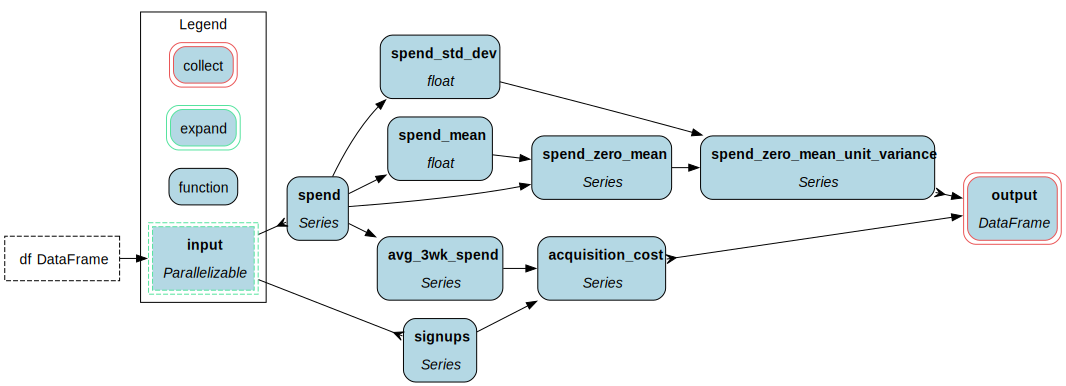

In [44]:
from decider.dag.builder import DeciderBuilder

dr = (
    DeciderBuilder()
    .with_config({})
    .include(EG1Module())
    .build()
)
dr

In [1]:
dr.execute(inputs={"df": pl.DataFrame({
    "spend": [100, 150, 200, 250, 300],
    "signups": [10, 15, 20, 25, 30]
})}, final_vars=["output"])

NameError: name 'dr' is not defined

In [ ]:
lf.map_batches(
    lambda df: pl.from_pandas(test(df.to_pandas())),
    schema={"x": pl.Float64, "y": pl.Float64, "z": pl.Float64}
).collect()